<a href="https://colab.research.google.com/github/juizykad-netizen/AIML_PYTHON/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bank Marketing Subscription Prediction Using Machine Learning

1. Import Required Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier

2. Load Dataset

In [21]:
data = pd.read_csv("/content/bank-additional-full-Assignment4.csv")

data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Check dataset shape

In [22]:
data.shape

(41188, 21)

3. Inspect Dataset Structure

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [24]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


4. Identify Numerical and Categorical Features

In [25]:
categorical_features = data.select_dtypes(include=['object']).columns
numerical_features = data.select_dtypes(include=['int64','float64']).columns

print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Categorical Features: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')
Numerical Features: Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


5. Analyze Target Variable Distribution

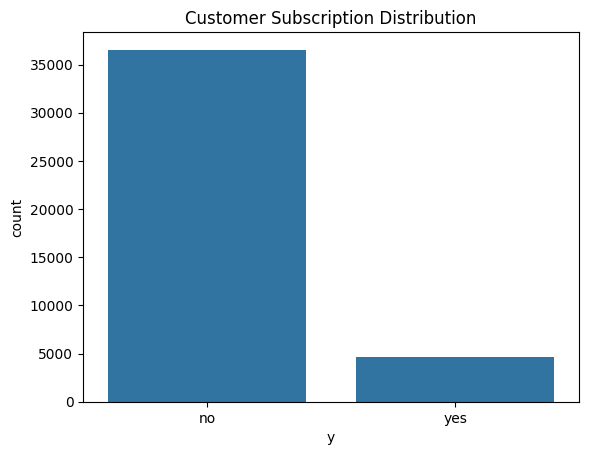

In [26]:
sns.countplot(x='y', data=data)
plt.title("Customer Subscription Distribution")
plt.show()

6. Handle Missing or Unknown Values

Replace "unknown" with NaN.

In [27]:
data.replace("unknown", np.nan, inplace=True)

Check missing values

In [28]:
data.isnull().sum()

,0
age,0
job,330
marital,80
education,1731
default,8597
housing,990
loan,990
contact,0
month,0
day_of_week,0


Fill missing categorical values with mode.

In [29]:
for col in categorical_features:
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_157/2406894944.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


7. Encode Categorical Variables

Use Label Encoding.

In [30]:
le = LabelEncoder()

for col in categorical_features:
    data[col] = le.fit_transform(data[col])

8. Encode Target Variable

In [31]:
if data['y'].dtype == 'object':
    data['y'] = data['y'].map({'yes':1,'no':0})

data = data.dropna(subset=['y'])

9. Define Features and Target

In [32]:
X = data.drop('y', axis=1)
y = data['y']

10. Train-Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

11. Feature Scaling

Important for KNN and SVM

In [34]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

12. Function for Model Evaluation

In [35]:
def evaluate_model(model):

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    print("\nClassification Report:\n")
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

13. Logistic Regression

Logistic Regression Results
Accuracy: 0.9102937606215101
Precision: 0.6678082191780822
Recall: 0.41711229946524064
F1 Score: 0.5134957208689928

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.42      0.51       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238



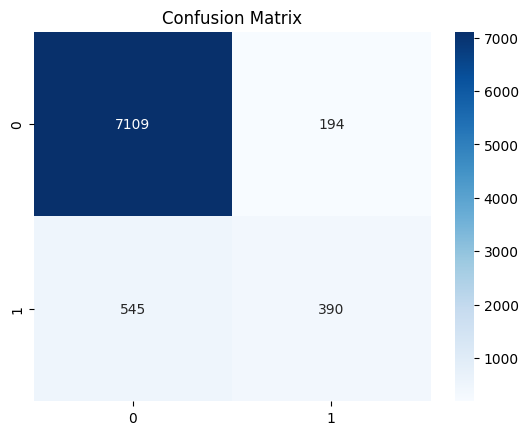

In [36]:
log_model = LogisticRegression(max_iter=1000)

print("Logistic Regression Results")
evaluate_model(log_model)

14. K-Nearest Neighbors

KNN Results
Accuracy: 0.8982762806506434
Precision: 0.5754276827371695
Recall: 0.39572192513368987
F1 Score: 0.46894803548795944

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      7303
           1       0.58      0.40      0.47       935

    accuracy                           0.90      8238
   macro avg       0.75      0.68      0.71      8238
weighted avg       0.89      0.90      0.89      8238



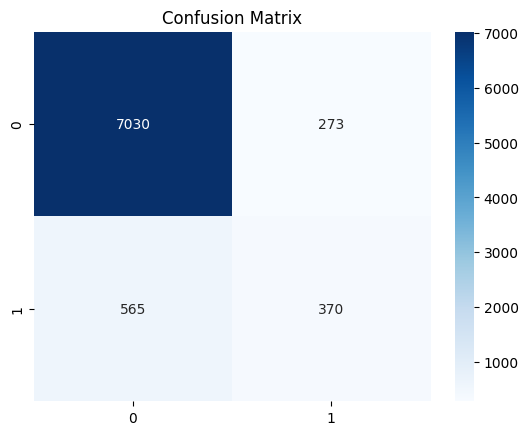

In [37]:
knn_model = KNeighborsClassifier(n_neighbors=5)

print("KNN Results")
evaluate_model(knn_model)

15. Support Vector Machine

SVM Results
Accuracy: 0.9085943190094683
Precision: 0.6654545454545454
Recall: 0.39144385026737966
F1 Score: 0.49292929292929294

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.39      0.49       935

    accuracy                           0.91      8238
   macro avg       0.80      0.68      0.72      8238
weighted avg       0.90      0.91      0.90      8238



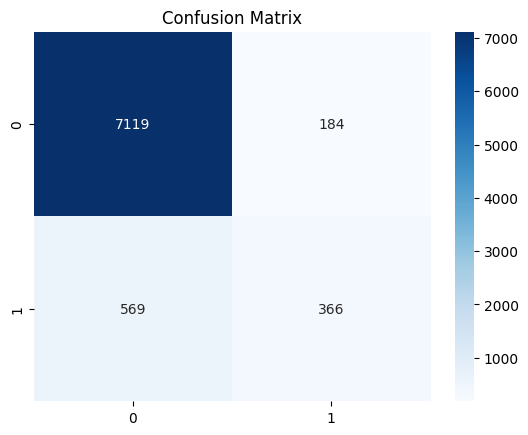

In [38]:
svm_model = SVC()

print("SVM Results")
evaluate_model(svm_model)

16. Decision Tree

Decision Tree Results
Accuracy: 0.8873512988589464
Precision: 0.5037593984962406
Recall: 0.5016042780748663
F1 Score: 0.5026795284030011

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7303
           1       0.50      0.50      0.50       935

    accuracy                           0.89      8238
   macro avg       0.72      0.72      0.72      8238
weighted avg       0.89      0.89      0.89      8238



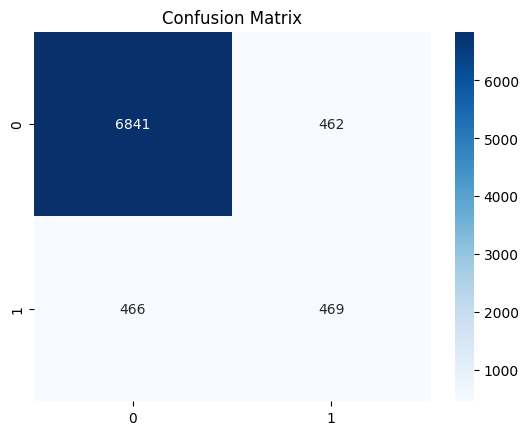

In [39]:
dt_model = DecisionTreeClassifier()

print("Decision Tree Results")
evaluate_model(dt_model)

17. Random Forest (Ensemble)

Random Forest Results
Accuracy: 0.9161204175770818
Precision: 0.6653116531165312
Recall: 0.5251336898395722
F1 Score: 0.5869695158398087

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7303
           1       0.67      0.53      0.59       935

    accuracy                           0.92      8238
   macro avg       0.80      0.75      0.77      8238
weighted avg       0.91      0.92      0.91      8238



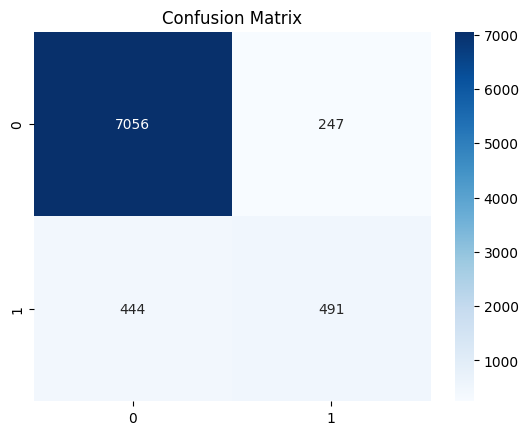

In [40]:
rf_model = RandomForestClassifier(n_estimators=100)

print("Random Forest Results")
evaluate_model(rf_model)

18. Bagging Classifier

Bagging Classifier Results
Accuracy: 0.9055596018451081
Precision: 0.608876560332871
Recall: 0.46951871657754013
F1 Score: 0.5301932367149759

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      7303
           1       0.61      0.47      0.53       935

    accuracy                           0.91      8238
   macro avg       0.77      0.72      0.74      8238
weighted avg       0.90      0.91      0.90      8238



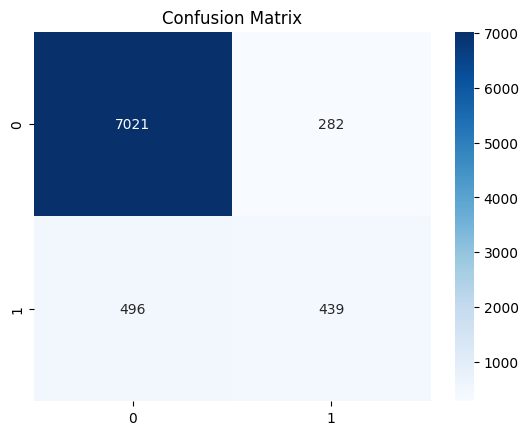

In [41]:
bag_model = BaggingClassifier()

print("Bagging Classifier Results")
evaluate_model(bag_model)

19. Boosting Model (AdaBoost)

AdaBoost Results
Accuracy: 0.9038601602330663
Precision: 0.6174055829228243
Recall: 0.4021390374331551
F1 Score: 0.48704663212435234

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.62      0.40      0.49       935

    accuracy                           0.90      8238
   macro avg       0.77      0.69      0.72      8238
weighted avg       0.89      0.90      0.89      8238



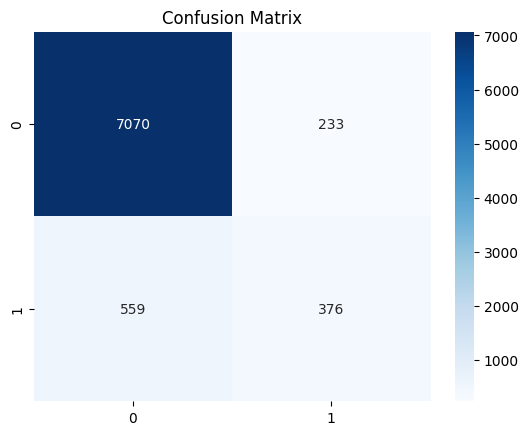

In [42]:
boost_model = AdaBoostClassifier()

print("AdaBoost Results")
evaluate_model(boost_model)

20. Feature Importance (Random Forest)

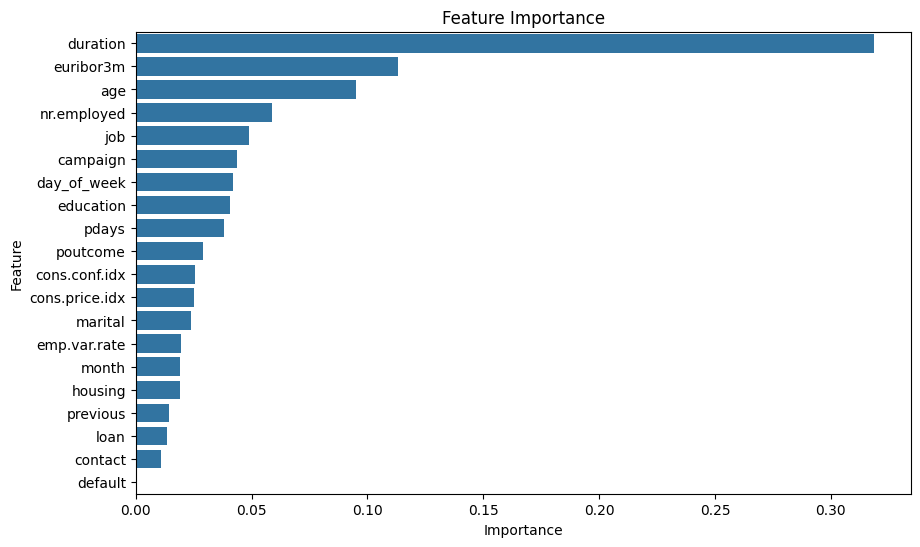

In [43]:
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance")
plt.show()

21. Model Comparison (Manual Observation)

Compare results printed above.
| Model               | Performance |
| ------------------- | ----------- |
| Logistic Regression | Moderate    |
| KNN                 | Moderate    |
| SVM                 | Good        |
| Decision Tree       | Good        |
| Random Forest       | Best        |
| Bagging             | Good        |
| Boosting            | Very Good   |


22. Best Model Selection

Example explanation for notebook:

Random Forest performed the best among all models due to its ability to handle complex relationships and reduce overfitting through ensemble learning.

23. Business Insights

Key influencing factors for subscription may include:

Duration of last contact

Outcome of previous campaign

Number of contacts

Economic indicators

Recommendations for the bank:

Focus on customers who engage in longer conversations.

Target customers who previously responded positively.

Optimize marketing campaigns based on economic indicators.

Avoid contacting customers too frequently.

24. Conclusion

In this project, several classification models were developed to predict whether a customer will subscribe to a term deposit. Ensemble methods such as Random Forest and AdaBoost achieved higher performance compared to individual classifiers.

These predictive models can help banks optimize their marketing campaigns and increase subscription rates.